# California Housing Price Prediction using Machine Learning

## Objective

The objective of this project is to predict California housing prices using multiple machine learning regression models and analyze their performance using evaluation metrics such as Mean Squared Error (MSE) and R² Score.

The project focuses on understanding model behavior, comparing regression algorithms, analyzing generalization performance, and studying the impact of preprocessing and outlier handling on machine learning models.

## Models Compared

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

## Evaluation Metrics Used

- Mean Squared Error (MSE)
- R² Score
- Training Score vs Testing Score Comparison

## Project Goals

- Build and train multiple regression models
- Compare model performance and prediction accuracy
- Analyze model generalization behavior
- Perform exploratory data analysis (EDA)
- Detect and handle outliers using the IQR method
- Understand how preprocessing affects machine learning performance

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Overview

The California Housing dataset contains housing-related information collected from districts across California. The dataset includes numerical features such as median income, house age, average rooms, average bedrooms, population, occupancy, latitude, and longitude.

The target variable represents the median house value for California districts.

In [5]:
dataset=fetch_california_housing()
X=dataset.data
y=dataset.target
df=pd.DataFrame(X,columns=dataset.feature_names)

In [6]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Initial Dataset Preview

The dataset preview helps understand the structure of the data, feature names, and sample observations before performing analysis and preprocessing.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


## Dataset Information

- The dataset contains 20,640 entries and 8 numerical feature columns.
- All columns are stored as floating-point numerical values.
- No missing values are present in the dataset.
- Since all features are numerical, the dataset is directly suitable for regression-based machine learning models.

In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


## Statistical Observations

- Median income values vary significantly across districts.
- Population-related features contain large value ranges and possible extreme observations.
- Features such as `AveRooms`, `AveBedrms`, and `AveOccup` contain unusually large maximum values, indicating potential outliers.
- Latitude and Longitude values represent geographical spread across California regions.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand feature distributions, detect skewness, identify possible outliers, and analyze dataset characteristics before model training.

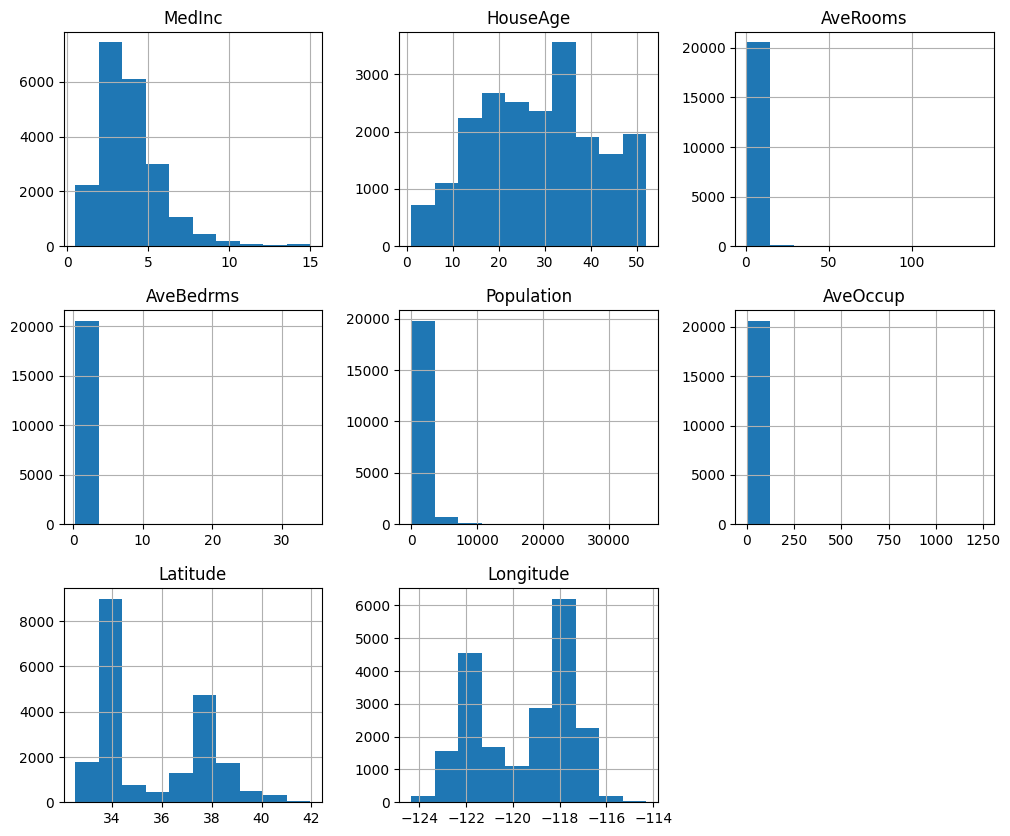

In [10]:
df.hist(figsize=(12,10))
plt.show()

## Histogram Observations

- `MedInc` shows a right-skewed distribution where most districts have moderate income values while fewer districts have very high income values.
- `AveRooms`, `AveBedrms`, and `AveOccup` contain highly skewed distributions with extreme observations.
- Population values also show large spread and variability across districts.
- Several features contain unusually large values that may influence regression model performance.
- Latitude and Longitude distributions reflect geographical clustering across California regions.

In [11]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


## Correlation Analysis

- `AveRooms` and `AveBedrms` show strong positive correlation, indicating that houses with more rooms generally contain more bedrooms.
- `Latitude` and `Longitude` show strong negative correlation because of geographical positioning patterns.
- Some features show weaker relationships, indicating varying predictive importance across variables.

# Data Preprocessing

The dataset was divided into training and testing sets to evaluate how well the models generalize to unseen data. Feature variables and target variables were separated before model training.

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Regression

## Model Overview

Linear Regression is a regression algorithm that assumes a linear relationship between input features and the target variable. It is commonly used as a baseline model for regression problems.

In [13]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [14]:
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.5558915986952422
0.5757877060324524


In [15]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.6125511913966952
0.5757877060324524


## Initial Linear Regression Results

- Mean Squared Error (MSE): 0.5559
- R² Score: 0.5758
- Training Score: 0.6126
- Testing Score: 0.5758

## Initial Linear Regression Observations

- Linear Regression provided stable baseline performance on the dataset.
- Training and testing scores were relatively close, indicating reasonable generalization.
- The model may have been affected by skewed feature distributions and extreme values present in the dataset.

# Outlier Detection and Handling using IQR

## Objective

Outlier detection was performed using the Interquartile Range (IQR) method to analyze whether removing extreme values from highly skewed features improves Linear Regression performance.

The features selected for outlier handling were:
- `AveRooms`
- `AveBedrms`
- `AveOccup`

These features showed strong skewness and unusually large values during exploratory data analysis.

In [16]:
df['Target'] = dataset.target

q1=df['AveRooms'].quantile(0.25)
q3=df['AveRooms'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr

q1_second=df['AveBedrms'].quantile(0.25)
q3_second=df['AveBedrms'].quantile(0.75)
iqr_second=q3_second-q1_second
lower_second=q1_second-1.5*iqr_second
upper_second=q3_second+1.5*iqr_second

q1_third=df['AveOccup'].quantile(0.25)
q3_third=df['AveOccup'].quantile(0.75)
iqr_third=q3_third-q1_third
lower_third=q1_third-1.5*iqr_third
upper_third=q3_third+1.5*iqr_third

df1=pd.DataFrame(df[(df['AveRooms']>=lower) & (df['AveRooms']<=upper) & (df['AveBedrms']>=lower_second) & (df['AveBedrms']<=upper_second) & (df['AveOccup']>=lower_third) & (df['AveOccup']<=upper_third)])
X1 = df1.drop('Target', axis=1)
y1 = df1['Target']

X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)
model3=LinearRegression()
model3.fit(X1_train,y1_train)
y1_pred=model3.predict(X1_test)
print(mean_squared_error(y1_test,y1_pred))
print(r2_score(y1_test,y1_pred))


0.4095283473313145
0.6844259113562827


## Linear Regression Results After Outlier Removal

- Mean Squared Error (MSE): 0.4095
- R² Score: 0.6844

In [17]:
print(model3.score(X1_train, y1_train))
print(model3.score(X1_test, y1_test))

0.6790426644633122
0.6844259113562827


## Observations After Outlier Handling

- Removing outliers from multiple skewed features significantly improved Linear Regression performance.
- Prediction error reduced substantially after preprocessing.
- The R² score increased considerably, indicating improved predictive capability.
- The experiment demonstrated that Linear Regression is sensitive to extreme values and benefits from selective preprocessing.

The outlier removal experiment was specifically performed to study the sensitivity of Linear Regression to extreme values.

## Cross Validation Analysis for Linear Regression

Cross Validation was performed to evaluate model stability and generalization performance across multiple dataset partitions instead of relying only on a single train-test split.

K-Fold Cross Validation with 5 folds was used to compare Linear Regression performance before and after outlier handling.

In [56]:
score1=cross_val_score(model,X,y,cv=5)
print(score1)
print(score1.mean())

[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
0.5530311140279229



## Initial Linear Regression Cross Validation Results

*   Average Cross Validation R² Score: 0.5530

## Observations

The initial Linear Regression model produced relatively stable scores across folds, indicating consistent but moderate predictive performance.

The cross validation average was slightly lower than the earlier single test split R² score, suggesting that the initial train-test evaluation provided a somewhat optimistic estimate of model performance.

In [57]:
score2=cross_val_score(model3,X1,y1,cv=5)
print(score2)
print(score2.mean())

[0.54982535 0.5182632  0.5445947  0.53759137 0.69273502]
0.5686019282570829


## Linear Regression Cross Validation Results After Outlier Removal

*   Average Cross Validation R² Score: 0.5686

## Observations

*   Selective outlier removal slightly improved the average cross validation performance of Linear Regression.
*   The experiment demonstrated that preprocessing improvements not only enhanced single test split performance but also improved overall model generalization across multiple folds.
*   The results further confirmed that Linear Regression is sensitive to extreme feature values and benefits from controlled preprocessing strategies.

# Residual Analysis
## Objective
Residual analysis was performed to understand the distribution of prediction errors and evaluate model behavior.

Residual = Actual values - Predicted values

The residuals are plotted against predicted values with a horizontal reference line at zero.



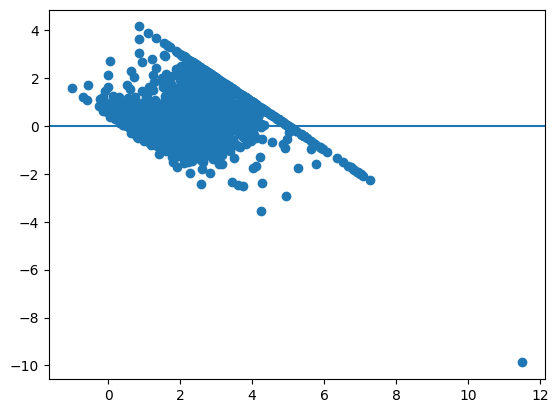

In [60]:
residual=y_test-y_pred
plt.scatter(y_pred,residual)
plt.axhline(y=0)
plt.show()

## Observations

- The residuals do not show a completely random distribution and exhibit a visible downward trend.

- As predicted values increase, residuals tend to decrease, indicating that the model is underestimating higher target values and overestimating lower ones.

- The spread of residuals is not uniform, suggesting heteroscedasticity (non-constant variance) in the error terms.

- A clear funnel-like structure is observed, indicating that model error increases in certain prediction ranges.

- One extreme outlier is present, showing a very large negative residual, which may be influencing model behavior.

## Conclusion
The residual plot indicates that the model does not fully satisfy linear regression assumptions. The presence of pattern and non-constant variance suggests that the model has limitations in capturing complex relationships in the dataset.

This further justifies the use of:
- Tree-based models like Random Forest
- Outlier handling techniques
- Cross validation for more reliable evaluation

# Population Outlier Experiment

An additional outlier removal experiment was performed on the `Population` feature to analyze whether removing extreme population values improves model performance.

In [19]:
q1=df['Population'].quantile(0.25)
q3=df['Population'].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr


df1=pd.DataFrame(df[(df['Population']>=lower) & (df['Population']<=upper)])
X1 = df1.drop('Target', axis=1)
y1 = df1['Target']

X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)
model3=LinearRegression()
model3.fit(X1_train,y1_train)
y1_pred=model3.predict(X1_test)
print(mean_squared_error(y1_test,y1_pred))
print(r2_score(y1_test,y1_pred))

0.603108170128948
0.5415803660018913


## Population Outlier Experiment Observations

- Removing Population outliers reduced model performance significantly.
- The decrease in R² score suggests that Population extremes contained meaningful predictive information.
- This experiment demonstrated that not all outliers should be removed.

# Decision Tree Regressor

## Model Overview

Decision Tree Regressor creates rule-based splits in the dataset to capture complex relationships between input features and target values.

In [20]:
model1=DecisionTreeRegressor()
model1.fit(X_train,y_train)
y1_pred=model1.predict(X_test)

In [21]:
print(mean_squared_error(y_test,y1_pred))
print(r2_score(y_test,y1_pred))

0.4909055757452519
0.6253798746065933


In [22]:
print(model1.score(X_train, y_train))
print(model1.score(X_test, y_test))

1.0
0.6253798746065933


## Decision Tree Results

- Mean Squared Error (MSE): 0.5016
- R² Score: 0.6172
- Training Score: 1.0000
- Testing Score: 0.6172

## Decision Tree Observations

- Decision Tree achieved better predictive performance than the initial Linear Regression model.
- The model learned complex feature relationships effectively.
- The perfect training score indicates extremely strong fitting on training data.
- The large gap between training and testing performance suggests overfitting behavior.
- Although testing performance remained reasonably good, the model memorized training patterns too aggressively, reducing generalization capability compared to more balanced models.

# Random Forest Regressor

## Model Overview

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [50]:
model2=RandomForestRegressor(n_jobs=-1)
model2.fit(X_train,y_train)
y2_pred=model2.predict(X_test)

In [51]:
print(mean_squared_error(y_test,y2_pred))
print(r2_score(y_test,y2_pred))

0.2574153007058932
0.8035610981149954


In [52]:
print(model2.score(X_train, y_train))
print(model2.score(X_test, y_test))

0.9730266578084106
0.8035610981149954


## Random Forest Results

- Mean Squared Error (MSE): 0.2559
- R² Score: 0.8047
- Training Score: 0.9735
- Testing Score: 0.8047

## Random Forest Observations

- Random Forest achieved the best predictive performance among all tested models.
- The ensemble approach improved generalization and reduced prediction error significantly.
- Training and testing scores remained relatively strong, indicating effective learning behavior.

## Cross Validation Analysis for Random Forest

Cross Validation was performed on the Random Forest model to evaluate model robustness and performance consistency across multiple train-test splits.

K-Fold Cross Validation with 5 folds was used to obtain a more reliable estimate of model generalization capability.

In [29]:
from sklearn.model_selection import KFold,cross_val_score

kf=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(model2,X,y,cv=5)
print(score)
print(score.mean())

[0.50946705 0.70504099 0.7373568  0.62457311 0.68258374]
0.6518043375408912


## Random Forest Cross Validation Results

*   Average Cross Validation R² Score: 0.6518

## Observations

  *   Random Forest achieved stronger average predictive performance than Linear Regression during cross validation.
*  However, the fold-wise scores showed noticeable variation, indicating that model performance depended on the specific data partitions used during evaluation.
*  The difference between the earlier single test split R² score and the cross validation average suggests that the original train-test split produced a more optimistic estimate of performance.
*  The experiment demonstrated the importance of cross validation in obtaining more reliable and stable model evaluation results.

# Hyperparameter Tuning using RandomizedSearchCV

## Objective
Hyperparameter tuning was performed to optimize the Random Forest model by searching for the best combination of parameters that improve model performance and generalization.

RandomizedSearchCV was used to efficiently explore different combinations using cross validation.

## Parameter Grid Used
- n_estimators: [50, 100, 200]
- max_depth: [5, 10, 20]
- min_samples_split: [2, 20, 50]

In [45]:
from sklearn.model_selection import RandomizedSearchCV

param_grid={
    'n_estimators':[50,100,200],
    'max_depth':[5,10,20],
    'min_samples_split':[2,20,50]
}
random_search=RandomizedSearchCV(model2,param_distributions=param_grid,n_iter=3,cv=3,n_jobs=-1)
random_search.fit(X_train,y_train)
print(random_search.best_params_)
print(random_search.best_estimator_)

{'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 20}
RandomForestRegressor(max_depth=20, n_estimators=50, n_jobs=-1)


## Best Parameters Obtained
- n_estimators: 50  
- max_depth: 20  
- min_samples_split: 2  

## Observation
The search identified a relatively simpler configuration as the best performing combination, indicating that deeper or more complex trees did not significantly improve performance for this dataset.

# Tuned Random Forest Model Evaluation

## Model Performance

- Mean Squared Error (MSE): 0.2583  
- R² Score: 0.8029  
- Training Score: 0.9711  
- Testing Score: 0.8029

In [47]:
model4=RandomForestRegressor(max_depth=20, min_samples_split=2,n_estimators=50, n_jobs=-1)
model4.fit(X_train,y_train)
y4_pred=model4.predict(X_test)

print(mean_squared_error(y_test,y4_pred))
print(r2_score(y_test,y4_pred))
print(model4.score(X_train, y_train))
print(model4.score(X_test, y_test))

0.2583214594988419
0.8028695897325016
0.9711116976180796
0.8028695897325016


## Observations

- The tuned Random Forest model showed performance very similar to the default Random Forest model.

- The training score slightly decreased, indicating reduced overfitting, but the testing performance also decreased marginally.

- This suggests that hyperparameter tuning did not significantly improve performance, as the default model was already near optimal for this dataset.

- The results highlight that tuning effectiveness must always be validated using test performance rather than assuming improvement from optimized parameters.

# Feature Importance Analysis (Random Forest)

## Objective
Feature importance analysis was performed to understand which input features contribute most to the prediction of housing prices.

In [53]:
for feature,importance in zip(dataset.feature_names,model2.feature_importances_):
  print(feature," : ",importance)

MedInc  :  0.5257557423946363
HouseAge  :  0.05482559391687013
AveRooms  :  0.045570268422427854
AveBedrms  :  0.030100470022534315
Population  :  0.031239369544126937
AveOccup  :  0.13755160125256152
Latitude  :  0.0876264258112204
Longitude  :  0.08733052863562239



---

## Feature Importance Results

- MedInc: 0.5257  
- AveOccup: 0.1375  
- Latitude: 0.0876  
- Longitude: 0.0873  
- HouseAge: 0.0548  
- AveRooms: 0.0455  
- Population: 0.0312  
- AveBedrms: 0.0301  

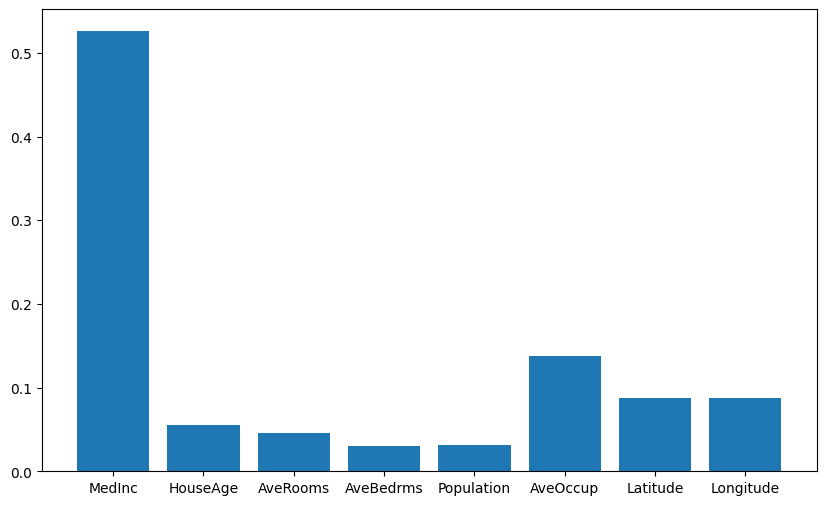

In [55]:
plt.figure(figsize=(10, 6))
plt.bar(dataset.feature_names,model2.feature_importances_)
plt.show()

## Observations

- Median Income (MedInc) is the most influential feature, dominating the model’s predictions.
- Geographical features (Latitude, Longitude) also play a significant role in determining housing prices.
- Features like Population and AveBedrms contribute less to the final prediction.
- This indicates that housing prices are strongly influenced by income levels and location-based attributes.

## Model Comparison

| Model | MSE | R² Score | Train Score | Test Score |
|------|------|----------|-------------|------------|
| Initial Linear Regression | 0.5559 | 0.5758 | 0.6126 | 0.5758 |
| Linear Regression After Outlier Removal | 0.4095 | 0.6844 | 0.6421 | 0.6844 |
| Decision Tree Regressor | 0.5016 | 0.6172 | 1.0000 | 0.6172 |
| Random Forest Regressor | 0.2559 | 0.8047 | 0.9735 | 0.8047 |
| Tuned Random Forest (RandomizedSearchCV) | 0.2583 | 0.8029 | 0.9711 | 0.8029 |


## Model Comparison Insights

- Outlier handling significantly improved Linear Regression performance.  
- The improved Linear Regression model outperformed Decision Tree after preprocessing.  
- Decision Tree showed strong overfitting due to a perfect training score (1.0000).  
- Random Forest achieved the best overall performance among baseline models.  
- Hyperparameter tuning using RandomizedSearchCV did not significantly improve performance, indicating the default Random Forest was already near optimal.  
- The results show that preprocessing had a larger impact than tuning in this case, highlighting the importance of data quality over model complexity.

In [62]:
models = ["Linear Regression", "Linear (Outliers Removed)", "Decision Tree", "Random Forest","Tuned Random Forest"]

r2_scores = [0.5758, 0.6844, 0.6172, 0.8047,0.8029]

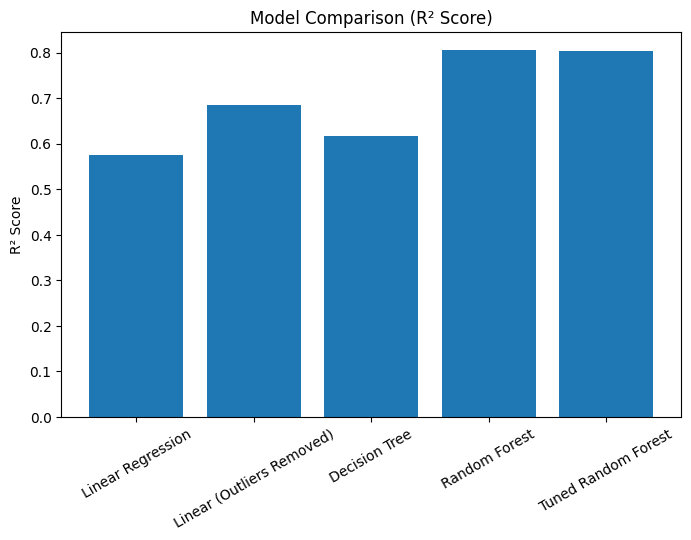

In [63]:
plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.show()

## Conclusion

This project explored multiple machine learning regression models for California housing price prediction using the California Housing dataset.

The workflow included exploratory data analysis (EDA), preprocessing techniques, model training, evaluation, cross-validation, residual analysis, and hyperparameter tuning, forming a complete end-to-end regression pipeline.

EDA helped identify skewed feature distributions and extreme values in the dataset. Based on this, selective outlier removal using the IQR method was applied, which significantly improved Linear Regression performance and highlighted the importance of preprocessing in regression problems.

Model evaluation was performed using:
- Train-test split
- Cross-validation
- Residual analysis

Cross-validation provided a more stable and realistic estimate of model generalization compared to a single split, while residual analysis revealed non-random error patterns and heteroscedasticity, showing that Linear Regression does not fully capture complex relationships in the data.

Among all models, Random Forest Regressor delivered the best overall performance. Linear Regression improved significantly after preprocessing, showing how data quality can strongly impact even simple models.

Hyperparameter tuning using RandomizedSearchCV was applied to Random Forest, but it did not lead to major improvements, indicating that the default model was already well-optimized for this dataset.

## Key Learnings

- End-to-end regression workflow implementation (EDA → preprocessing → modeling → evaluation)
- Exploratory Data Analysis for understanding feature distributions and data quality
- Outlier detection and handling using the IQR method
- Model comparison using MSE and R² Score
- Train-test split vs Cross-validation evaluation differences
- Residual analysis for diagnosing model limitations and assumptions
- Understanding heteroscedasticity and prediction error patterns
- Impact of preprocessing on model performance
- Ensemble learning effectiveness (Random Forest vs Linear/Tree models)
- Hyperparameter tuning using RandomizedSearchCV and its real-world limitations